# Sprint 2 — GNN Modeling and Training

Notebook trình bày các bước chuẩn bị graph, định nghĩa GCN/GraphSAGE/RGCN,
neighbor sampling, loss, metric, training loop, early stopping và lưu artifact.

Mặc định notebook chạy `QUICK_MODE` để kiểm tra pipeline. Kết quả quick mode không
được dùng làm kết luận; các bảng chính thức nằm trong notebook 03.

## Protocol chống leakage

- Loss và `pos_weight` chỉ dùng train labels.
- Checkpoint được chọn bằng validation Average Precision.
- Test chỉ chạy sau khi checkpoint đã được chọn.
- Cùng split, seed, fan-out và ngân sách train được giữ khi so sánh model.

In [1]:
from copy import deepcopy
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
import hashlib
import json
import platform
import random
import statistics
import time
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import sklearn
from sklearn.metrics import average_precision_score, roc_auc_score
import torch
from torch import Tensor, nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import GCNConv, RGCNConv, SAGEConv
from torch_geometric.utils import to_undirected
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Không tìm thấy project root")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "dgraphfin.npz"
RUN_ROOT = PROJECT_ROOT / "artifacts" / "runs"
DEVICE = torch.device("cpu")

QUICK_MODE = True
SELECTED_EXPERIMENT = "baseline_full_zero_indicator"
SELECTED_MODEL = "graphsage"
SELECTED_SEED = 42
RUN_OFFICIAL_EXPERIMENT = False

plt.style.use("seaborn-v0_8-whitegrid")
print(f"PyTorch {torch.__version__} | PyG {torch_geometric.__version__} | device={DEVICE}")

PyTorch 2.12.0+cpu | PyG 2.8.0.post1 | device=cpu


## 1. Cấu hình thí nghiệm

Baseline và toàn bộ one-factor-at-a-time ablation được khai báo ngay trong notebook.
Mỗi ablation chỉ đổi một yếu tố so với GCN zero-indicator directed.

In [2]:
BASE_EXPERIMENT = {
    "data_path": "data/dgraphfin.npz",
    "output_root": "artifacts/runs",
    "device": "cpu",
    "feature_mode": "zero_indicator",
    "feature_standardization": "none",
    "graph_direction": "directed",
    "relation_mode": "original",
    "seeds": [42, 43, 44],
    "models": ["gcn"],
    "model": {
        "in_channels": 34,
        "hidden_channels": 64,
        "num_layers": 2,
        "dropout": 0.5,
        "num_relations": None,
    },
    "sampling": {"num_neighbors": [15, 10], "batch_size": 1024, "num_workers": 0},
    "training": {
        "epochs": 50,
        "learning_rate": 0.001,
        "weight_decay": 0.0005,
        "early_stopping_patience": 8,
        "use_pos_weight": True,
        "gradient_clip_norm": 2.0,
        "max_train_batches": None,
        "max_eval_batches": None,
    },
}


def make_experiment(run_name: str, **overrides) -> dict:
    """Create an independent experiment config from the shared protocol."""
    config = deepcopy(BASE_EXPERIMENT)
    config["run_name"] = run_name
    for section, values in overrides.items():
        if isinstance(values, dict) and isinstance(config.get(section), dict):
            config[section].update(values)
        else:
            config[section] = values
    return config


EXPERIMENTS = {
    "baseline_full": make_experiment(
        "baseline_full",
        feature_mode="raw",
        models=["gcn", "graphsage"],
        model={"in_channels": 17},
    ),
    "baseline_full_zero_indicator": make_experiment(
        "baseline_full_zero_indicator", models=["gcn", "graphsage"]
    ),
    "gcn_ablation_standardized": make_experiment(
        "gcn_ablation_standardized", feature_standardization="global_zscore"
    ),
    "gcn_ablation_dropout0": make_experiment(
        "gcn_ablation_dropout0", model={"dropout": 0.0}
    ),
    "gcn_ablation_weight_decay_5e7": make_experiment(
        "gcn_ablation_weight_decay_5e7", training={"weight_decay": 0.0000005}
    ),
    "gcn_ablation_lr001": make_experiment(
        "gcn_ablation_lr001", training={"learning_rate": 0.01}
    ),
    "gcn_graphsage_ablation_undirected": make_experiment(
        "gcn_graphsage_ablation_undirected",
        graph_direction="undirected",
        models=["gcn", "graphsage"],
    ),
    "rgcn_background_full": make_experiment(
        "rgcn_background_full",
        relation_mode="target_background",
        models=["rgcn"],
        model={"hidden_channels": 13, "num_relations": 4},
    ),
}

config = deepcopy(EXPERIMENTS[SELECTED_EXPERIMENT])
if QUICK_MODE:
    config["training"].update(
        {"epochs": 2, "early_stopping_patience": 2, "max_train_batches": 2, "max_eval_batches": 2}
    )

display(pd.json_normalize(config).T.rename(columns={0: "value"}))

,value
data_path,data/dgraphfin.npz
output_root,artifacts/runs
device,cpu
feature_mode,zero_indicator
feature_standardization,none
graph_direction,directed
relation_mode,original
seeds,"[42, 43, 44]"
models,"[gcn, graphsage]"
run_name,baseline_full_zero_indicator


## 2. Load và kiểm tra dữ liệu cho modeling

Notebook 01 có validation đầy đủ. Ở đây ta lặp lại các điều kiện tối thiểu cần cho
training để notebook vẫn chạy độc lập.

In [3]:
REQUIRED_KEYS = (
    "x", "y", "edge_index", "edge_type", "edge_timestamp",
    "train_mask", "valid_mask", "test_mask",
)


@dataclass(slots=True)
class DGraphDataset:
    x: np.ndarray
    y: np.ndarray
    edge_index: np.ndarray
    edge_type: np.ndarray
    edge_timestamp: np.ndarray
    train_mask: np.ndarray
    valid_mask: np.ndarray
    test_mask: np.ndarray

    @property
    def num_nodes(self) -> int:
        return int(self.x.shape[0])


def load_dgraphfin(path: str | Path) -> DGraphDataset:
    """Load DGraphFin with canonical dtypes and no pickle support."""
    with np.load(Path(path), allow_pickle=False) as archive:
        missing = sorted(set(REQUIRED_KEYS) - set(archive.files))
        if missing:
            raise ValueError(f"Dataset thiếu trường: {missing}")
        dataset = DGraphDataset(
            x=np.asarray(archive["x"], dtype=np.float32),
            y=np.asarray(archive["y"], dtype=np.int64),
            edge_index=np.asarray(archive["edge_index"], dtype=np.int64),
            edge_type=np.asarray(archive["edge_type"], dtype=np.int64),
            edge_timestamp=np.asarray(archive["edge_timestamp"], dtype=np.int64),
            train_mask=np.asarray(archive["train_mask"], dtype=np.int64),
            valid_mask=np.asarray(archive["valid_mask"], dtype=np.int64),
            test_mask=np.asarray(archive["test_mask"], dtype=np.int64),
        )
    if dataset.x.ndim != 2 or dataset.x.shape[1] != 17:
        raise ValueError(f"Expected x shape [N, 17], got {dataset.x.shape}")
    if dataset.edge_index.ndim != 2 or dataset.edge_index.shape[1] != 2:
        raise ValueError(f"Expected edge_index shape [E, 2], got {dataset.edge_index.shape}")
    split_indices = np.concatenate((dataset.train_mask, dataset.valid_mask, dataset.test_mask))
    if not np.isin(dataset.y[split_indices], [0, 1]).all():
        raise ValueError("Prediction splits contain labels outside 0/1")
    return dataset


dataset = load_dgraphfin(DATA_PATH)
print(f"{dataset.num_nodes:,} nodes | {dataset.edge_index.shape[0]:,} directed edges | {dataset.x.shape[1]} features")

3,700,550 nodes | 4,300,999 directed edges | 17 features


## 3. Feature preprocessing và PyG graph

`zero_indicator` thay `-1` bằng 0 rồi nối thêm 17 cờ missing. Với RGCN-BG, relation
chỉ mã hóa target/background (`T→T`, `T→B`, `B→T`, `B→B`), không tiết lộ node fraud.

In [4]:
def transform_features(x: np.ndarray, mode: str) -> np.ndarray:
    """Apply the selected missing-value representation."""
    source = np.asarray(x, dtype=np.float32)
    if mode == "raw":
        return source
    if mode == "zero_indicator":
        missing = source == -1
        filled = np.where(missing, 0.0, source).astype(np.float32, copy=False)
        return np.concatenate((filled, missing.astype(np.float32)), axis=1)
    raise ValueError("feature_mode must be 'raw' or 'zero_indicator'")


def standardize_features(x: np.ndarray) -> np.ndarray:
    """Global per-column z-score used only in the explicit standardization ablation."""
    source = np.asarray(x, dtype=np.float32)
    mean = source.mean(axis=0, dtype=np.float64).astype(np.float32)
    std = source.std(axis=0, dtype=np.float64).astype(np.float32)
    safe_std = np.where(std > 0, std, 1).astype(np.float32)
    result = source.copy()
    np.subtract(result, mean, out=result)
    np.divide(result, safe_std, out=result)
    return result


def target_background_edge_type(labels: Tensor, edge_index: Tensor) -> Tensor:
    """Encode 0=T→T, 1=T→B, 2=B→T and 3=B→B."""
    source_is_target = labels[edge_index[0]] <= 1
    destination_is_target = labels[edge_index[1]] <= 1
    return (~source_is_target).long() * 2 + (~destination_is_target).long()


def prepare_pyg_data(dataset: DGraphDataset, config: dict) -> Data:
    """Apply configured transforms without modifying the original NumPy arrays."""
    x = transform_features(dataset.x, config["feature_mode"])
    if config["feature_standardization"] == "global_zscore":
        x = standardize_features(x)

    data = Data(
        x=torch.from_numpy(x),
        y=torch.from_numpy(dataset.y),
        edge_index=torch.from_numpy(np.ascontiguousarray(dataset.edge_index.T)),
        edge_type=torch.from_numpy(dataset.edge_type),
        edge_timestamp=torch.from_numpy(dataset.edge_timestamp),
        train_idx=torch.from_numpy(dataset.train_mask),
        valid_idx=torch.from_numpy(dataset.valid_mask),
        test_idx=torch.from_numpy(dataset.test_mask),
    )
    data.directed = True

    if config["graph_direction"] == "undirected":
        data.edge_index, edge_attributes = to_undirected(
            data.edge_index,
            edge_attr=[data.edge_type, data.edge_timestamp],
            num_nodes=data.num_nodes,
            reduce="min",
        )
        data.edge_type, data.edge_timestamp = edge_attributes
        data.directed = False
    if config["relation_mode"] == "target_background":
        data.edge_type = target_background_edge_type(data.y, data.edge_index)
    return data


data = prepare_pyg_data(dataset, config)
print(data)
print(f"Feature mode: {config['feature_mode']} → {data.x.shape[1]} dimensions")

Data(x=[3700550, 34], edge_index=[2, 4300999], y=[3700550], edge_type=[4300999], edge_timestamp=[4300999], train_idx=[857899], valid_idx=[183862], test_idx=[183840], directed=True)
Feature mode: zero_indicator → 34 dimensions


## 4. Class imbalance và neighbor loaders

`pos_weight = normal_train / fraud_train` chỉ dùng train split. Evaluation subset của
quick mode được chọn ngẫu nhiên với seed cố định thay vì lấy theo thứ tự node.

In [5]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def class_balance(data: Data, use_pos_weight: bool) -> dict[str, float | int]:
    train_labels = data.y[data.train_idx]
    negative_count = int((train_labels == 0).sum())
    positive_count = int((train_labels == 1).sum())
    if positive_count == 0:
        raise ValueError("Train split không có fraud node")
    return {
        "negative_count": negative_count,
        "positive_count": positive_count,
        "positive_weight": negative_count / positive_count if use_pos_weight else 1.0,
    }


def fixed_random_subset(indices: Tensor, limit: int | None, seed: int) -> Tensor:
    if limit is None or indices.numel() <= limit:
        return indices
    generator = torch.Generator().manual_seed(seed)
    positions = torch.randperm(indices.numel(), generator=generator)[:limit]
    return indices[positions]


def build_neighbor_loaders(data: Data, config: dict, seed: int) -> dict[str, NeighborLoader]:
    sampling = config["sampling"]
    training = config["training"]
    common = {
        "data": data,
        "num_neighbors": sampling["num_neighbors"],
        "batch_size": sampling["batch_size"],
        "num_workers": sampling["num_workers"],
        "subgraph_type": "directional",
    }
    evaluation_limit = (
        None
        if training["max_eval_batches"] is None
        else training["max_eval_batches"] * sampling["batch_size"]
    )
    evaluation_seed = config["seeds"][0]
    return {
        "train": NeighborLoader(
            input_nodes=data.train_idx,
            shuffle=True,
            generator=torch.Generator().manual_seed(seed),
            **common,
        ),
        "validation": NeighborLoader(
            input_nodes=fixed_random_subset(data.valid_idx, evaluation_limit, evaluation_seed + 10_000),
            shuffle=False,
            **common,
        ),
        "test": NeighborLoader(
            input_nodes=fixed_random_subset(data.test_idx, evaluation_limit, evaluation_seed + 20_000),
            shuffle=False,
            **common,
        ),
    }


balance = class_balance(data, config["training"]["use_pos_weight"])
loaders = build_neighbor_loaders(data, config, SELECTED_SEED)
display(pd.DataFrame([balance]))
first_batch = next(iter(loaders["train"]))
print(first_batch)

,negative_count,positive_count,positive_weight
0,847042,10857,78.018053


Data(x=[3105, 34], edge_index=[2, 2493], y=[3105], edge_type=[2493], edge_timestamp=[2493], train_idx=[857899], valid_idx=[183862], test_idx=[183840], directed=True, n_id=[3105], e_id=[2493], num_sampled_nodes=[3], num_sampled_edges=[2], input_id=[1024], batch_size=1024)


## 5. Kiến trúc GCN, GraphSAGE và RGCN

Mỗi model trả về một fraud logit trên mỗi node. Chỉ các seed node đầu batch tham gia
loss/metric; neighbor node chỉ cung cấp context cho message passing.

In [6]:
class BaseNodeClassifier(nn.Module):
    """Shared validation for sampled-subgraph binary node classifiers."""

    @staticmethod
    def validate_inputs(x: Tensor, edge_index: Tensor) -> None:
        if x.ndim != 2:
            raise ValueError(f"x must have shape [N, F], got {tuple(x.shape)}")
        if edge_index.ndim != 2 or edge_index.shape[0] != 2:
            raise ValueError(f"edge_index must have shape [2, E], got {tuple(edge_index.shape)}")
        if edge_index.dtype != torch.long:
            raise TypeError("edge_index must use torch.long")


class GCN(BaseNodeClassifier):
    """Two-layer Graph Convolutional Network."""

    def __init__(self, in_channels: int, hidden_channels: int, num_layers: int, dropout: float):
        super().__init__()
        self.dropout = dropout
        channels = [in_channels] + [hidden_channels] * (num_layers - 1) + [1]
        self.convs = nn.ModuleList(
            GCNConv(channels[i], channels[i + 1], cached=False, add_self_loops=True, normalize=True)
            for i in range(num_layers)
        )

    def forward(self, x: Tensor, edge_index: Tensor, edge_type: Tensor | None = None) -> Tensor:
        self.validate_inputs(x, edge_index)
        for conv in self.convs[:-1]:
            x = F.dropout(F.relu(conv(x, edge_index)), p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index).squeeze(-1)


class GraphSAGE(BaseNodeClassifier):
    """Mean-aggregation GraphSAGE baseline."""

    def __init__(self, in_channels: int, hidden_channels: int, num_layers: int, dropout: float):
        super().__init__()
        self.dropout = dropout
        channels = [in_channels] + [hidden_channels] * (num_layers - 1) + [1]
        self.convs = nn.ModuleList(
            SAGEConv(channels[i], channels[i + 1], aggr="mean", normalize=False, root_weight=True)
            for i in range(num_layers)
        )

    def forward(self, x: Tensor, edge_index: Tensor, edge_type: Tensor | None = None) -> Tensor:
        self.validate_inputs(x, edge_index)
        for conv in self.convs[:-1]:
            x = F.dropout(F.relu(conv(x, edge_index)), p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index).squeeze(-1)


class RGCN(BaseNodeClassifier):
    """Relation-aware GCN for four target/background endpoint relations."""

    def __init__(
        self,
        in_channels: int,
        hidden_channels: int,
        num_layers: int,
        dropout: float,
        num_relations: int,
    ):
        super().__init__()
        self.dropout = dropout
        self.num_relations = num_relations
        channels = [in_channels] + [hidden_channels] * (num_layers - 1) + [1]
        self.convs = nn.ModuleList(
            RGCNConv(channels[i], channels[i + 1], num_relations=num_relations, root_weight=True, bias=True)
            for i in range(num_layers)
        )

    def forward(self, x: Tensor, edge_index: Tensor, edge_type: Tensor | None = None) -> Tensor:
        self.validate_inputs(x, edge_index)
        if edge_type is None or edge_type.shape != (edge_index.shape[1],):
            raise ValueError("RGCN requires edge_type with shape [E]")
        for conv in self.convs[:-1]:
            x = F.dropout(F.relu(conv(x, edge_index, edge_type)), p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index, edge_type).squeeze(-1)


def build_model(name: str, model_config: dict) -> BaseNodeClassifier:
    """Build one supported baseline from the visible notebook configuration."""
    kwargs = {key: value for key, value in model_config.items() if key != "num_relations"}
    if name == "gcn":
        return GCN(**kwargs)
    if name == "graphsage":
        return GraphSAGE(**kwargs)
    if name == "rgcn":
        return RGCN(**kwargs, num_relations=model_config["num_relations"])
    raise ValueError(f"Unsupported model: {name}")


model = build_model(SELECTED_MODEL, config["model"])
print(model)
print(f"Trainable parameters: {sum(parameter.numel() for parameter in model.parameters()):,}")

GraphSAGE(
  (convs): ModuleList(
    (0): SAGEConv(34, 64, aggr=mean)
    (1): SAGEConv(64, 1, aggr=mean)
  )
)
Trainable parameters: 4,545


## 6. Metric, loss và training loop

`BCEWithLogitsLoss` ổn định số học hơn việc sigmoid trước loss. Gradient được clip;
best state được giữ trong memory theo validation AP và test chỉ đánh giá state đó.

In [7]:
def compute_binary_metrics(labels: np.ndarray, probabilities: np.ndarray) -> dict[str, float | int]:
    """Compute imbalance-aware binary metrics with explicit validation."""
    y_true = np.asarray(labels, dtype=np.int64).reshape(-1)
    y_score = np.asarray(probabilities, dtype=np.float64).reshape(-1)
    if y_true.shape != y_score.shape or y_true.size == 0:
        raise ValueError("labels and probabilities must be non-empty and have the same shape")
    if not np.isin(y_true, [0, 1]).all() or np.unique(y_true).size != 2:
        raise ValueError("ROC-AUC/AP require both binary classes")
    return {
        "roc_auc": float(roc_auc_score(y_true, y_score)),
        "average_precision": float(average_precision_score(y_true, y_score)),
        "sample_count": int(y_true.size),
        "positive_count": int(y_true.sum()),
    }


def train_one_epoch(model, loader, optimizer, criterion, training_config, seed, epoch):
    model.train()
    set_seed(seed + epoch)
    weighted_loss, seed_total, batch_count = 0.0, 0, 0
    for batch_index, batch in enumerate(loader):
        if training_config["max_train_batches"] is not None and batch_index >= training_config["max_train_batches"]:
            break
        batch = batch.to(DEVICE)
        seed_count = int(batch.batch_size)
        targets = batch.y[:seed_count].float()
        optimizer.zero_grad(set_to_none=True)
        logits = model(batch.x, batch.edge_index, getattr(batch, "edge_type", None))[:seed_count]
        loss = criterion(logits, targets)
        if not torch.isfinite(loss):
            raise FloatingPointError("Loss is not finite")
        loss.backward()
        if training_config["gradient_clip_norm"] is not None:
            nn.utils.clip_grad_norm_(model.parameters(), training_config["gradient_clip_norm"])
        optimizer.step()
        weighted_loss += float(loss.detach()) * seed_count
        seed_total += seed_count
        batch_count += 1
    if seed_total == 0:
        raise RuntimeError("No training batch was processed")
    return weighted_loss / seed_total, batch_count, seed_total


@torch.no_grad()
def evaluate(model, loader, seed):
    model.eval()
    set_seed(seed)
    labels, probabilities = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        seed_count = int(batch.batch_size)
        logits = model(batch.x, batch.edge_index, getattr(batch, "edge_type", None))[:seed_count]
        labels.append(batch.y[:seed_count].cpu().numpy())
        probabilities.append(torch.sigmoid(logits).cpu().numpy())
    return compute_binary_metrics(np.concatenate(labels), np.concatenate(probabilities))


def train_model(data: Data, model_name: str, config: dict, seed: int, verbose: bool = True):
    """Train one seed, select by validation AP, then evaluate test once."""
    set_seed(seed)
    model = build_model(model_name, config["model"]).to(DEVICE)
    training_config = config["training"]
    balance = class_balance(data, training_config["use_pos_weight"])
    loaders = build_neighbor_loaders(data, config, seed)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=training_config["learning_rate"],
        weight_decay=training_config["weight_decay"],
    )
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(balance["positive_weight"], dtype=torch.float32, device=DEVICE)
    )

    history, best_state, best_validation = [], None, None
    best_epoch, epochs_without_improvement = 0, 0
    for epoch in range(1, training_config["epochs"] + 1):
        started = time.perf_counter()
        loss, batches, seed_nodes = train_one_epoch(
            model, loaders["train"], optimizer, criterion, training_config, seed, epoch
        )
        validation = evaluate(model, loaders["validation"], seed + 10_000)
        record = {
            "epoch": epoch,
            "train_loss": loss,
            "train_batches": batches,
            "train_seed_nodes": seed_nodes,
            "validation": validation,
            "seconds": time.perf_counter() - started,
        }
        history.append(record)
        if verbose:
            print(f"epoch={epoch:02d} loss={loss:.5f} valid_AP={validation['average_precision']:.5f}")

        if best_validation is None or validation["average_precision"] > best_validation["average_precision"]:
            best_state = deepcopy(model.state_dict())
            best_validation = validation
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= training_config["early_stopping_patience"]:
            break

    model.load_state_dict(best_state)
    test = evaluate(model, loaders["test"], seed + 20_000)
    payload = {
        "model": model_name,
        "seed": seed,
        "parameter_count": sum(parameter.numel() for parameter in model.parameters()),
        "positive_weight": balance["positive_weight"],
        "best_epoch": best_epoch,
        "epochs_completed": len(history),
        "stopped_early": len(history) < training_config["epochs"],
        "validation": best_validation,
        "test": test,
        "history": history,
    }
    return model, payload, best_state

In [8]:
quick_started = time.perf_counter()
model, quick_result, _ = train_model(data, SELECTED_MODEL, config, SELECTED_SEED)
quick_result["run_elapsed_seconds"] = time.perf_counter() - quick_started

display(pd.DataFrame([
    {
        "mode": "quick" if QUICK_MODE else "full",
        "model": quick_result["model"],
        "best_epoch": quick_result["best_epoch"],
        "validation_ROC_AUC": quick_result["validation"]["roc_auc"],
        "validation_AP": quick_result["validation"]["average_precision"],
        "test_ROC_AUC": quick_result["test"]["roc_auc"],
        "test_AP": quick_result["test"]["average_precision"],
    }
]).round(6))

epoch=01 loss=1.36593 valid_AP=0.01722
epoch=02 loss=1.40229 valid_AP=0.02066


,mode,model,best_epoch,validation_ROC_AUC,validation_AP,test_ROC_AUC,test_AP
0,quick,graphsage,2,0.611181,0.020664,0.585235,0.024585


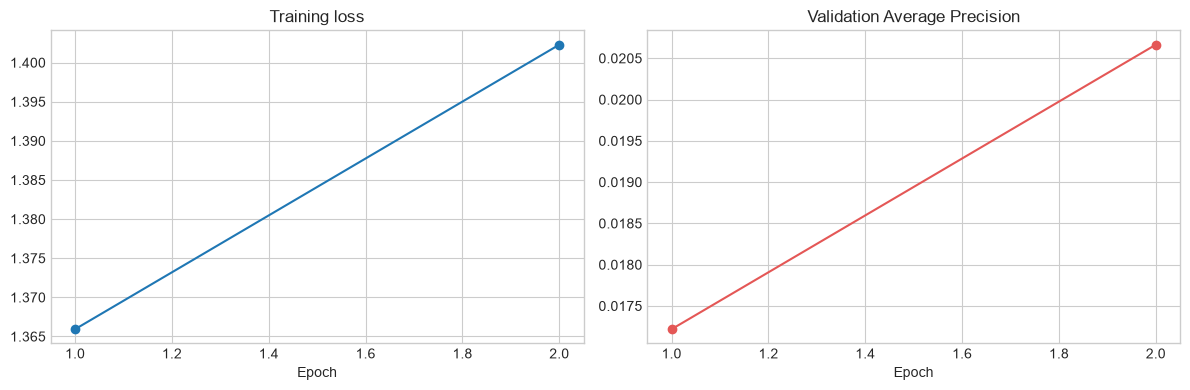

In [9]:
history_df = pd.DataFrame(
    {
        "epoch": [row["epoch"] for row in quick_result["history"]],
        "train_loss": [row["train_loss"] for row in quick_result["history"]],
        "validation_AP": [row["validation"]["average_precision"] for row in quick_result["history"]],
    }
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o")
axes[0].set_title("Training loss")
axes[1].plot(history_df["epoch"], history_df["validation_AP"], marker="o", color="#E45756")
axes[1].set_title("Validation Average Precision")
for axis in axes:
    axis.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

## 7. Chạy và lưu full experiment

Cell dưới chứa đầy đủ orchestration để lưu config, checkpoint, metric từng seed và
`comparison.json`. Để tránh vô tình chạy nhiều giờ, nó chỉ thực thi khi đặt
`RUN_OFFICIAL_EXPERIMENT = True` ở đầu notebook. Chạy từng experiment trong registry,
sau đó notebook 03 có thể dựng lại result catalog.

In [10]:
def file_sha256(path: str | Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def json_dump(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")


def aggregate_metric(results: list[dict], split: str, metric: str) -> dict[str, float]:
    values = [float(result[split][metric]) for result in results]
    return {
        "mean": statistics.fmean(values),
        "std": statistics.pstdev(values) if len(values) > 1 else 0.0,
        "min": min(values),
        "max": max(values),
    }


def environment_versions() -> dict[str, str | bool]:
    return {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "numpy": np.__version__,
        "torch": torch.__version__,
        "torch_geometric": torch_geometric.__version__,
        "scikit_learn": sklearn.__version__,
        "cuda_available": torch.cuda.is_available(),
    }


def run_experiment(experiment_config: dict) -> Path:
    """Run every configured model/seed and persist auditable raw artifacts."""
    if any(experiment_config["training"][key] is not None for key in ("max_train_batches", "max_eval_batches")):
        raise ValueError("Official experiment must not limit train/evaluation batches")

    started = time.perf_counter()
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = RUN_ROOT / f"{experiment_config['run_name']}_{timestamp}"
    run_dir.mkdir(parents=True, exist_ok=False)
    json_dump(run_dir / "config.json", experiment_config)

    experiment_dataset = load_dgraphfin(PROJECT_ROOT / experiment_config["data_path"])
    experiment_data = prepare_pyg_data(experiment_dataset, experiment_config)
    del experiment_dataset

    process = psutil.Process()
    all_results = {name: [] for name in experiment_config["models"]}
    for model_name in experiment_config["models"]:
        for seed in experiment_config["seeds"]:
            run_started = time.perf_counter()
            trained_model, result, best_state = train_model(
                experiment_data, model_name, experiment_config, seed, verbose=True
            )
            result["process_rss_mib_at_end"] = process.memory_info().rss / 1024**2
            result["run_elapsed_seconds"] = time.perf_counter() - run_started

            model_dir = run_dir / f"{model_name}_seed{seed}"
            model_dir.mkdir()
            torch.save(
                {
                    "model": model_name,
                    "seed": seed,
                    "model_config": experiment_config["model"],
                    "best_epoch": result["best_epoch"],
                    "best_validation_ap": result["validation"]["average_precision"],
                    "state_dict": best_state,
                },
                model_dir / "best.pt",
            )
            json_dump(model_dir / "metrics.json", result)
            all_results[model_name].append(result)
            del trained_model, best_state

    relation_values, relation_counts = torch.unique(experiment_data.edge_type, return_counts=True)
    comparison = {
        "run_name": experiment_config["run_name"],
        "mode": "full",
        "is_partial_evaluation": False,
        "selection_metric": "validation.average_precision",
        "test_used_for_selection": False,
        "feature_mode": experiment_config["feature_mode"],
        "feature_standardization": experiment_config["feature_standardization"],
        "graph_direction": experiment_config["graph_direction"],
        "relation_mode": experiment_config["relation_mode"],
        "relation_type_counts": {
            str(int(key)): int(value)
            for key, value in zip(relation_values, relation_counts, strict=True)
        },
        "data_sha256": file_sha256(PROJECT_ROOT / experiment_config["data_path"]),
        "environment": environment_versions(),
        "elapsed_seconds": time.perf_counter() - started,
        "models": {},
    }
    for model_name, results in all_results.items():
        comparison["models"][model_name] = {
            "runs": results,
            "aggregate": {
                f"{split}_{metric}": aggregate_metric(results, split, metric)
                for split in ("validation", "test")
                for metric in ("roc_auc", "average_precision")
            },
        }
    json_dump(run_dir / "comparison.json", comparison)
    return run_dir

In [11]:
if RUN_OFFICIAL_EXPERIMENT:
    official_config = deepcopy(EXPERIMENTS[SELECTED_EXPERIMENT])
    output_directory = run_experiment(official_config)
    print("Official artifact saved to:", output_directory)
else:
    print("Full run đang tắt. Đặt RUN_OFFICIAL_EXPERIMENT=True khi chủ động chạy thí nghiệm chính thức.")

Full run đang tắt. Đặt RUN_OFFICIAL_EXPERIMENT=True khi chủ động chạy thí nghiệm chính thức.


## 8. Kết luận phạm vi

Notebook này hoàn chỉnh luồng node-level static/transductive cho GCN, GraphSAGE và
RGCN. GAT, TGAT, temporal modeling và trích xuất fraud ring được để cho sprint sau,
đúng với phạm vi đã thống nhất.